In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from copy import deepcopy

# ==================== Utility Functions ====================

def scale_zeropoint(rmin, rmax, qmin, qmax, asymmetric=True):
    """Calculate scale and zero point for quantization."""
    if asymmetric:
        scale = (rmax - rmin) / (qmax - qmin)
        scale = torch.where(scale == 0, torch.ones_like(scale), scale)
        zeropoints = torch.round(qmin - rmin / scale)
        zeropoints = torch.clamp(zeropoints, qmin, qmax)
    else:
        absmax = torch.max(rmin.abs(), rmax.abs())
        scale = absmax / ((qmax - qmin) / 2)
        scale = torch.where(scale == 0, torch.ones_like(scale), scale)
        zeropoints = torch.zeros_like(scale)
    return scale, zeropoints


def scale_zero_channel(weight_tensor, qmin, qmax, asymmetric=True):
    """Calculate per-channel scale and zero point for weights."""
    rmin = weight_tensor.view(weight_tensor.shape[0], -1).min(dim=1)[0]
    rmax = weight_tensor.view(weight_tensor.shape[0], -1).max(dim=1)[0]
    
    if asymmetric:
        scales = (rmax - rmin) / (qmax - qmin)
        scales = torch.where(scales == 0, torch.ones_like(scales), scales)
        zeropoints = torch.round(qmin - rmin / scales)
        zeropoints = torch.clamp(zeropoints, qmin, qmax)
    else:
        absmax = torch.max(rmin.abs(), rmax.abs())
        scales = absmax / ((qmax - qmin) / 2)
        scales = torch.where(scales == 0, torch.ones_like(scales), scales)
        zeropoints = torch.zeros_like(scales)
    
    return scales, zeropoints


def fold_bn_into_conv(conv, bn):
    """Fold batch normalization into convolution layer."""
    W = conv.weight.data
    b = conv.bias.data if conv.bias is not None else torch.zeros(W.size(0), device=W.device)
    
    gamma = bn.weight.data
    beta = bn.bias.data
    mean = bn.running_mean
    var = bn.running_var
    eps = bn.eps
    
    std = torch.sqrt(var + eps)
    W_folded = W * (gamma / std).reshape(-1, 1, 1, 1)
    b_folded = beta + (b - mean) * (gamma / std)
    
    conv.weight.data = W_folded
    if conv.bias is None:
        conv.bias = nn.Parameter(b_folded)
    else:
        conv.bias.data = b_folded
    
    return conv


def bnfold_vgg(model, device="cuda"):
    """Fold all batch normalization layers in VGG model."""
    model = model.to(device)
    layers = list(model.features)
    new_layers = []
    i = 0
    
    while i < len(layers):
        if (isinstance(layers[i], nn.Conv2d) and 
            i + 1 < len(layers) and 
            isinstance(layers[i + 1], nn.BatchNorm2d)):
            conv_folded = fold_bn_into_conv(layers[i], layers[i + 1])
            new_layers.append(conv_folded)
            i += 2
        else:
            new_layers.append(layers[i])
            i += 1
    
    model.features = nn.Sequential(*new_layers)
    return model


# ==================== Packing/Unpacking for INT4 ====================

def pack_int4(x: torch.Tensor) -> torch.ByteTensor:
    """Pack int8 tensor into int4 format (2 values per byte)."""
    assert x.dtype == torch.int8
    assert torch.all((x >= -8) & (x <= 7)), "Values must be in [-8, 7] range for int4"
    
    flat = x.flatten()
    if flat.numel() % 2 != 0:
        flat = torch.cat([flat, torch.zeros(1, dtype=torch.int8, device=x.device)])
    
    flat_unsigned = (flat & 0x0F).to(torch.uint8)
    high = flat_unsigned[0::2] << 4
    low = flat_unsigned[1::2]
    packed = high | low
    
    return packed


def unpack_int4(packed: torch.ByteTensor, original_shape) -> torch.Tensor:
    """Unpack int4 format back to int8 tensor."""
    assert packed.dtype == torch.uint8
    
    high = (packed >> 4) & 0x0F
    low = packed & 0x0F
    vals = torch.stack((high, low), dim=-1).flatten()
    vals = vals.to(torch.int8)
    vals = (vals ^ 0x08) - 0x08
    
    return vals[:torch.prod(torch.tensor(original_shape))].view(original_shape)


# ==================== Calibration for PTQ ====================

def calibrate_model(model, dataloader, device, num_batches=100, bitwidth=8):
    model.eval()
    
    qmin = -2**(bitwidth - 1)
    qmax = 2**(bitwidth - 1) - 1
    act_in_mins, act_in_maxs = {}, {}
    act_out_mins, act_out_maxs = {}, {}

    def register_hook(name):
        def forward_hook(module, input_val, output_val):
            if isinstance(input_val, tuple): input_val = input_val[0]
            act_in_mins.setdefault(name, []).append(input_val.detach().min().item())
            act_in_maxs.setdefault(name, []).append(input_val.detach().max().item())
            act_out_mins.setdefault(name, []).append(output_val.detach().min().item())
            act_out_maxs.setdefault(name, []).append(output_val.detach().max().item())
        return forward_hook

    hook_handles = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            handle = module.register_forward_hook(register_hook(name))
            hook_handles.append(handle)

    with torch.no_grad():
        for i, (images, _) in enumerate(dataloader):
            if i >= num_batches:
                break
            model(images.to(device))
    
    for handle in hook_handles:
        handle.remove()
        
    act_quant_params = {}
    for name in act_in_mins:
        rmin_in = np.mean(act_in_mins[name])
        rmax_in = np.mean(act_in_maxs[name])
        rmin_out = np.mean(act_out_mins[name])
        rmax_out = np.mean(act_out_maxs[name])

        scale_in, zp_in = scale_zeropoint(
            torch.tensor(rmin_in, dtype=torch.float32), torch.tensor(rmax_in, dtype=torch.float32), qmin, qmax
        )
        scale_out, zp_out = scale_zeropoint(
            torch.tensor(rmin_out, dtype=torch.float32), torch.tensor(rmax_out, dtype=torch.float32), qmin, qmax
        )
        
        act_quant_params[name] = {
            "scale_act": scale_in.to(device),
            "zp_act": zp_in.to(device),
            "scale_out": scale_out.to(device),
            "zp_out": zp_out.to(device)
        }
        
    return act_quant_params

# ==================== Post-Training Quantization (PTQ) ====================

def quantize_weight(weight, bitwidth=8, per_channel=True, asymmetric=True):
    qmin = -2**(bitwidth - 1)
    qmax = 2**(bitwidth - 1) - 1
    
    if per_channel:
        scales, zeropoints = scale_zero_channel(weight, qmin, qmax, asymmetric=asymmetric)
        scales = scales.view(-1, 1, 1, 1) if weight.dim() == 4 else scales.view(-1, 1)
        zeropoints = zeropoints.view(-1, 1, 1, 1) if weight.dim() == 4 else zeropoints.view(-1, 1)
    else:
        rmin = weight.min()
        rmax = weight.max()
        scales, zeropoints = scale_zeropoint(rmin, rmax, qmin, qmax, asymmetric=asymmetric)
    
    weight_q = torch.clamp(torch.round(weight / scales + zeropoints), qmin, qmax)
    
    return weight_q.to(torch.int8), scales.squeeze(), zeropoints.squeeze()

def apply_ptq(model, act_quant_params, bitwidth=8, weight_q_config=None):
    if weight_q_config is None:
        weight_q_config = {'per_channel': True, 'asymmetric': True}
    for name, module in model.named_modules():
        if name in act_quant_params:
            weight_q, scale_w, zp_w = quantize_weight(
                module.weight.data, 
                bitwidth, 
                **weight_q_config
            )
            
            del module._parameters['weight']
            module.register_buffer("weight_q", weight_q)
            module.register_buffer("scale_w", scale_w)
            module.register_buffer("zp_w", zp_w)

            if module.bias is not None:
                module.register_buffer("bias_fp32", module.bias.data.clone())
                del module._parameters['bias']
            
            params = act_quant_params[name]
            module.register_buffer("scale_act", params["scale_act"])
            module.register_buffer("zp_act", params["zp_act"])
            module.register_buffer("scale_out", params["scale_out"])
            module.register_buffer("zp_out", params["zp_out"])
    
    return model


# ==================== Quantized Layers ====================
class QIntLayer(nn.Module):
    """Statically quantized integer layer."""
    def __init__(self, layer, bitwidth=8):
        super().__init__()
        self.is_conv = isinstance(layer, nn.Conv2d)
        self.bitwidth = bitwidth
        
        self.qmin = -2**(self.bitwidth - 1)
        self.qmax = 2**(self.bitwidth - 1) - 1

        self.register_buffer("weight_q", layer.get_buffer("weight_q"))
        self.register_buffer("scale_w", layer.get_buffer("scale_w"))
        self.register_buffer("zp_w", layer.get_buffer("zp_w"))
        self.register_buffer("scale_act", layer.get_buffer("scale_act"))
        self.register_buffer("zp_act", layer.get_buffer("zp_act"))
        self.register_buffer("scale_out", layer.get_buffer("scale_out"))
        self.register_buffer("zp_out", layer.get_buffer("zp_out"))
        
        if "bias_fp32" in dict(layer.named_buffers()):
            bias_fp32 = layer.get_buffer("bias_fp32")
            scale_bias = self.scale_act * self.scale_w.view(1, -1)
            bias_q = torch.round(bias_fp32.view(1, -1) / (scale_bias + 1e-8)).to(torch.int32)
            self.register_buffer("bias_q", bias_q.squeeze())
        else:
            self.bias_q = None
            
        if self.is_conv:
            self.stride = layer.stride
            self.padding = layer.padding
            self.dilation = layer.dilation
            self.groups = layer.groups
        M_unshaped = (self.scale_act * self.scale_w) / (self.scale_out + 1e-8)
        if self.is_conv:
            M = M_unshaped.view(1, -1, 1, 1)
        else: 
            M = M_unshaped.view(1, -1)

        self.register_buffer("M", M)

    def forward(self, x_fp: torch.Tensor):
        x_q = torch.clamp(torch.round(x_fp / self.scale_act + self.zp_act), 
                         self.qmin, self.qmax).to(torch.int8)
        
        x_q_shifted = x_q.to(torch.int32) - self.zp_act.to(torch.int32)
        w_q_shifted = self.weight_q.to(torch.int32)
        zp_w_shifted = self.zp_w.to(torch.int32)

        if self.is_conv:
            w_q_shifted = w_q_shifted - zp_w_shifted.view(-1, 1, 1, 1)
        else:
            w_q_shifted = w_q_shifted - zp_w_shifted.view(-1, 1)
        if self.is_conv:
            acc = F.conv2d(x_q_shifted.float(), w_q_shifted.float(), bias=None, 
                          stride=self.stride, padding=self.padding, 
                          dilation=self.dilation, groups=self.groups)
        else:
            acc = F.linear(x_q_shifted.float(), w_q_shifted.float(), bias=None)
        
        if self.bias_q is not None:
            if self.is_conv:
                acc += self.bias_q.view(1, -1, 1, 1)
            else:
                acc += self.bias_q
                
        y_q = torch.round(acc * self.M + self.zp_out)
        y_q = torch.clamp(y_q, self.qmin, self.qmax)
        y_fp = (y_q - self.zp_out) * self.scale_out
        return y_fp

# ==================== (FIXED) Quantization-Aware Training Components ====================

class FakeQuantize(nn.Module):
    def __init__(self, bitwidth=8, per_channel=False, asymmetric=True, channel_dim=0, ema_momentum=0.1):
        super().__init__()
        self.bitwidth = bitwidth
        self.qmin = -2**(bitwidth - 1)
        self.qmax = 2**(bitwidth - 1) - 1
        self.per_channel = per_channel
        self.asymmetric = asymmetric
        self.channel_dim = channel_dim
        self.ema_momentum = ema_momentum
        
        self.register_buffer('scale', torch.tensor(1.0))
        self.register_buffer('zero_point', torch.tensor(0.0))
        self.register_buffer('min_val', torch.tensor(float('inf')))
        self.register_buffer('max_val', torch.tensor(float('-inf')))

    def forward(self, x):
        if self.training:
            if self.per_channel and x.dim() > 1:
                dims = list(range(x.dim()))
                dims.pop(self.channel_dim)
                batch_min = x.amin(dim=dims, keepdim=True).detach()
                batch_max = x.amax(dim=dims, keepdim=True).detach()
            else:
                batch_min = x.min().detach()
                batch_max = x.max().detach()

            if self.min_val.isinf():
                self.min_val.copy_(batch_min)
                self.max_val.copy_(batch_max)
            else:
                self.min_val.mul_(1.0 - self.ema_momentum).add_(batch_min * self.ema_momentum)
                self.max_val.mul_(1.0 - self.ema_momentum).add_(batch_max * self.ema_momentum)
            
            rmin, rmax = self.min_val, self.max_val
            current_scale, current_zero_point = scale_zeropoint(rmin, rmax, self.qmin, self.qmax, self.asymmetric)
        else:
            current_scale, current_zero_point = self.scale, self.zero_point

        x_q = torch.clamp(torch.round(x / current_scale + current_zero_point), self.qmin, self.qmax)
        x_dq = (x_q - current_zero_point) * current_scale
        return x + (x_dq - x).detach()

    def freeze_quantization_params(self):
        final_scale, final_zero_point = scale_zeropoint(self.min_val, self.max_val, self.qmin, self.qmax, self.asymmetric)
        self.scale.copy_(final_scale)
        self.zero_point.copy_(final_zero_point)

class QATConv2d(nn.Module):
    def __init__(self, conv_layer, bitwidth=8, weight_q_config=None):
        super().__init__()
        self.conv = conv_layer
        self.bitwidth = bitwidth
        if weight_q_config is None:
            weight_q_config = {'per_channel': True, 'asymmetric': True}
        self.weight_fake_quant = FakeQuantize(bitwidth, **weight_q_config, channel_dim=0)
        self.act_fake_quant = FakeQuantize(bitwidth, per_channel=False, asymmetric=True)
        self.output_fake_quant = FakeQuantize(bitwidth, per_channel=False, asymmetric=True)

    def forward(self, x):
        x = self.act_fake_quant(x)
        weight_q = self.weight_fake_quant(self.conv.weight)
        output = F.conv2d(x, weight_q, self.conv.bias, 
                         self.conv.stride, self.conv.padding,
                         self.conv.dilation, self.conv.groups)
        output = self.output_fake_quant(output)
        return output

class QATLinear(nn.Module):
    def __init__(self, linear_layer, bitwidth=8, weight_q_config=None):
        super().__init__()
        self.linear = linear_layer
        self.bitwidth = bitwidth
        if weight_q_config is None:
            weight_q_config = {'per_channel': True, 'asymmetric': True}
        self.weight_fake_quant = FakeQuantize(bitwidth, **weight_q_config, channel_dim=0)
        self.act_fake_quant = FakeQuantize(bitwidth, per_channel=False, asymmetric=True)
        self.output_fake_quant = FakeQuantize(bitwidth, per_channel=False, asymmetric=True)

    def forward(self, x):
        x = self.act_fake_quant(x)
        weight_q = self.weight_fake_quant(self.linear.weight)
        output = F.linear(x, weight_q, self.linear.bias)
        output = self.output_fake_quant(output)
        return output

def prepare_qat_model(model, bitwidth=8, weight_q_config=None):
    def _prepare(module):
        for name, child in list(module.named_children()):
            if isinstance(child, nn.Conv2d):
                setattr(module, name, QATConv2d(child, bitwidth, weight_q_config))
            elif isinstance(child, nn.Linear):
                setattr(module, name, QATLinear(child, bitwidth, weight_q_config))
            else:
                _prepare(child)
        return module
    return _prepare(model)

def convert_qat_to_int_model(qat_model, bitwidth=8, sym=True):
    qat_model.eval()
    for module in qat_model.modules():
        if isinstance(module, FakeQuantize):
            module.freeze_quantization_params()

    model_to_convert = deepcopy(qat_model)
    
    if sym:
        weight_q_config = {'per_channel': False, 'asymmetric': False}
    else:
        weight_q_config = {'per_channel': True, 'asymmetric': True}

    def _convert(module):
        for name, child in list(module.named_children()):
            if isinstance(child, (QATConv2d, QATLinear)):
                original_layer = child.conv if isinstance(child, QATConv2d) else child.linear
                
                weight_q, scale_w, zp_w = quantize_weight(
                    original_layer.weight.data, bitwidth, **weight_q_config
                )
                
                del original_layer._parameters['weight']
                original_layer.register_buffer("weight_q", weight_q)
                original_layer.register_buffer("scale_w", scale_w)
                original_layer.register_buffer("zp_w", zp_w)

                if original_layer.bias is not None:
                    original_layer.register_buffer("bias_fp32", original_layer.bias.data.clone())
                    del original_layer._parameters['bias']
                
                act_quantizer = child.act_fake_quant
                output_quantizer = child.output_fake_quant
                original_layer.register_buffer("scale_act", act_quantizer.scale)
                original_layer.register_buffer("zp_act", act_quantizer.zero_point)
                original_layer.register_buffer("scale_out", output_quantizer.scale)
                original_layer.register_buffer("zp_out", output_quantizer.zero_point)
                
                quantized_int_layer = QIntLayer(original_layer, bitwidth)
                setattr(module, name, quantized_int_layer)
            else:
                _convert(child)
        return module

    return _convert(model_to_convert)

# ==================== Model Conversion and Helper Functions ====================

def convert_to_qint_model(model, bitwidth=8):
    def _convert(module):
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if hasattr(module, 'weight_q'):
                return QIntLayer(module, bitwidth)
            else:
                return module
        for name, child in list(module.named_children()):
            setattr(module, name, _convert(child))
        return module
    
    return _convert(deepcopy(model))

def get_model_size(model, bitwidth=None):
    size_in_bytes = 0
    state_dict = model.state_dict()
    
    for name, tensor in state_dict.items():
        is_quantized_weight = name.endswith('.weight_q')

        if is_quantized_weight and bitwidth is not None:
            if bitwidth == 4:
                packed_tensor = pack_int4(tensor.cpu())
                size_in_bytes += packed_tensor.nelement() * packed_tensor.element_size()
            else:
                size_in_bytes += tensor.nelement() * (bitwidth / 8)
        else:
            size_in_bytes += tensor.nelement() * tensor.element_size()
            
    size_mb = size_in_bytes / (1024 * 1024)
    return size_mb

def evaluate(model, data_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# ==================== Main Pipelines ====================

def ptq_pipeline(model, calibration_loader, device, bitwidth=8, static=True, sym=True):
    model_copy = deepcopy(model)
    model_copy = bnfold_vgg(model_copy, device)
    
    print("Calibrating model for PTQ...")
    act_quant_params = calibrate_model(model_copy, calibration_loader, device, bitwidth=bitwidth)
    if sym:
        weight_q_config = {'per_channel': False, 'asymmetric': False}
    else:
        weight_q_config = {'per_channel': True, 'asymmetric': True}

    print("Applying PTQ quantization parameters...")
    model_prepared = apply_ptq(model_copy, act_quant_params, bitwidth, weight_q_config=weight_q_config)
    
    if static:
        final_model = convert_to_qint_model(model_prepared, bitwidth)
    else:
        raise NotImplementedError("Dynamic PTQ is not part of this workflow.")
    
    print("PTQ completed!")
    return final_model

def qat_pipeline(model, train_loader, val_loader, calibration_loader, device, bitwidth=8, 
                 epochs=5, lr=1e-5, sym=True): 
    print(f"Starting Integrated QAT with bitwidth={bitwidth}, epochs={epochs}, lr={lr}")
    model_copy = deepcopy(model)
    model_copy = bnfold_vgg(model_copy, device)
    
    if sym:
        print("Configuring QAT for Symmetric, Per-Tensor weights.")
        weight_q_config = {'per_channel': False, 'asymmetric': False}
    else:
        print("Configuring QAT for Asymmetric, Per-Channel weights.")
        weight_q_config = {'per_channel': True, 'asymmetric': True}

    print("Preparing model for Integrated QAT...")
    qat_model = prepare_qat_model(model_copy, bitwidth, weight_q_config)
    qat_model = qat_model.to(device)
    
    print("Training QAT model...")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(qat_model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        qat_model.train()
        running_loss = 0.0
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = qat_model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        qat_model.eval()
        for module in qat_model.modules():
            if isinstance(module, FakeQuantize):
                module.freeze_quantization_params()

        val_acc = evaluate(qat_model, val_loader, device)
        avg_loss = running_loss / len(train_loader)
        
        print(f"QAT Epoch {epoch+1}/{epochs} | Training Loss: {avg_loss:.3f} | Validation Accuracy (Q-Sim): {val_acc:.2f}%")

    print("\nConverting trained QAT model to final integer format...")
    final_quantized_model = convert_qat_to_int_model(qat_model, bitwidth, sym=sym)
    
    print("Integrated QAT completed!")
    return final_quantized_model

# ==================== Mixed-Precision and Visualization Code (Unchanged) ====================

class MixedPrecisionManager:
    def __init__(self, model, dataloader):
        self.model = model
        self.dataloader = dataloader
        self.variances = {}

    def _profile_hook(self, name):
        def hook(module, input, output):
            var = torch.var(output.detach()).item()
            if name in self.variances:
                self.variances[name].append(var)
            else:
                self.variances[name] = [var]
        return hook

    def profile_activation_variance(self, num_batches=50, device="cuda"):
        self.model.eval()
        self.model.to(device)
        self.variances = {}
        hooks = []

        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                hooks.append(module.register_forward_hook(self._profile_hook(name)))
        
        with torch.no_grad():
            for i, (images, _) in enumerate(self.dataloader):
                if i >= num_batches:
                    break
                images = images.to(device)
                self.model(images)
        
        for hook in hooks:
            hook.remove()
        
        avg_variances = {name: np.mean(vals) for name, vals in self.variances.items()}
        return avg_variances

    @staticmethod
    def get_quantization_policy(variances, sensitivity_percentile=0.8, 
                                high_precision_bits=32, low_precision_bits=8):
        policy = {}
        variance_values = list(variances.values())
        if not variance_values:
            return {}
            
        threshold = np.percentile(variance_values, sensitivity_percentile * 100)
        
        for name, var in variances.items():
            if var >= threshold:
                policy[name] = high_precision_bits
            else:
                policy[name] = low_precision_bits
        
        return policy

import matplotlib.pyplot as plt

class ActivationVisualizer:
    def __init__(self, model, layers_to_watch):
        self.model = model
        self.layers_to_watch = layers_to_watch
        self.activations = {name: [] for name in layers_to_watch}
        self.hooks = []
        self._register_hooks()

    def _hook_fn(self, name):
        def hook(module, input, output):
            self.activations[name].append(output.detach().cpu())
        return hook

    def _register_hooks(self):
        for name, module in self.model.named_modules():
            if name in self.layers_to_watch:
                self.hooks.append(module.register_forward_hook(self._hook_fn(name)))

    def capture_activations(self, data_loader, device, num_batches=1):
        self.model.eval()
        with torch.no_grad():
            for i, (images, _) in enumerate(data_loader):
                if i >= num_batches:
                    break
                self.model(images.to(device))

    def plot_histograms(self):
        num_layers = len(self.layers_to_watch)
        fig, axes = plt.subplots(2, (num_layers + 1) // 2, figsize=(num_layers * 2.5, 8))
        axes = axes.flatten()
        fig.suptitle('Activation Distributions Across Layers', fontsize=18, fontweight='bold')

        for ax, name in zip(axes, self.layers_to_watch):
            acts = torch.cat(self.activations[name]).flatten().numpy()
            ax.hist(acts, bins=100, color='royalblue', alpha=0.8, density=True)
            ax.set_title(f"{name}", fontsize=10)
            ax.set_xlabel('Activation', fontsize=9)
            ax.grid(alpha=0.3)

        for ax in axes[len(self.layers_to_watch):]:
            ax.axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

In [2]:
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import os
import numpy as np
import subprocess
from torch.profiler import profile, ProfilerActivity

def profile_model_performance(model, model_name, model_size_mb, dataloader, device, num_batches=50, warmup_batches=10):
    try:
        model_dtype = next(model.parameters()).dtype
    except StopIteration:
        model_dtype = torch.float32
    model.to(device)
    model.eval()
    latencies, peak_mems, avg_mems = [], [], []
    with torch.no_grad():
        for i, (inputs, _) in enumerate(dataloader):
            if i >= warmup_batches:
                break
            _ = model(inputs.to(device, dtype=model_dtype))
    with torch.no_grad():
        for i, (inputs, _) in enumerate(dataloader):
            if i >= num_batches:
                break
            inputs = inputs.to(device, dtype=model_dtype)
            if device == "cuda":
                torch.cuda.reset_peak_memory_stats(device)
                torch.cuda.synchronize()
            start_time = time.perf_counter()
            with profile(activities=[ProfilerActivity.CUDA], profile_memory=True) as prof:
                _ = model(inputs)
            if device == "cuda":
                torch.cuda.synchronize()
            end_time = time.perf_counter()
            latencies.append((end_time - start_time) * 1000)
            if device == "cuda":
                peak_mems.append(torch.cuda.max_memory_allocated(device) / (1024 * 1024))
                avg_mems.append(torch.cuda.memory_allocated(device) / (1024 * 1024))
    avg_latency = np.mean(latencies) if latencies else 0
    total_time_sec = np.sum(latencies) / 1000
    total_images = min(num_batches, len(dataloader)) * dataloader.batch_size
    throughput = total_images / total_time_sec if total_time_sec > 0 else 0
    avg_peak_mem = np.mean(peak_mems) if peak_mems else 0
    avg_used_mem = np.mean(avg_mems) if avg_mems else 0
    energy_mJ = None
    if device == "cuda":
        powers, batch_times = [], []
        with torch.no_grad():
            for i, (inputs, _) in enumerate(dataloader):
                if i >= num_batches:
                    break
                inputs = inputs.to(device, dtype=model_dtype)
                torch.cuda.synchronize()
                start = time.perf_counter()
                _ = model(inputs)
                torch.cuda.synchronize()
                end = time.perf_counter()
                batch_times.append(end - start)
                try:
                    device_id = torch.cuda.current_device()
                    output = subprocess.check_output(
                        f"nvidia-smi --query-gpu=power.draw --format=csv,noheader,nounits -i {device_id}",
                        shell=True
                    ).decode("utf-8").strip()
                    powers.append(float(output))
                except Exception:
                    pass
        if powers and batch_times:
            avg_power = np.mean(powers)
            total_time = np.sum(batch_times)
            energy_mJ = avg_power * total_time * 1000
    results = {
        "Model": model_name,
        "Size (MB)": f"{model_size_mb:.2f}",
        "Avg Latency (ms/batch)": f"{avg_latency:.2f}",
        "Throughput (img/sec)": f"{throughput:.2f}",
        # "Peak GPU Memory (MB)": f"{avg_peak_mem:.2f}" if device == "cuda" else "N/A",
        # "Avg GPU Memory (MB)": f"{avg_used_mem:.2f}" if device == "cuda" else "N/A",
        # "Energy (mJ)": f"{energy_mJ:.2f}" if energy_mJ is not None else "Unavailable",
    }
    return results


In [3]:
import torch
import torch.nn as nn
import time
import numpy as np
import torch.optim as optim
def evaluate(model, data_loader, device):
    model.to(device)
    model.eval()
    try:
        model_dtype = next(model.parameters()).dtype
    except StopIteration:
        model_dtype = torch.float32
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            images = images.to(dtype=model_dtype)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def measure_latency(model, device, dummy_input):
    """Measures average inference latency."""
    model.to(device)
    model.eval()
    dummy_input = dummy_input.to(device)
    
    # Warm-up runs
    for _ in range(10):
        _ = model(dummy_input)
        
    # Measurement runs
    latencies = []
    with torch.no_grad():
        for _ in range(100):
            start_time = time.time()
            _ = model(dummy_input)
            torch.cuda.synchronize() # Wait for the operation to complete
            end_time = time.time()
            latencies.append((end_time - start_time) * 1000) # milliseconds
            
    return np.mean(latencies)
DEVICE = "cuda"

def train_baseline(model, train_loader, test_loader, epochs=20, lr=0.01):
    """A simple training loop for the baseline model."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        val_acc = evaluate(model, test_loader, DEVICE)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.3f}, Val Acc: {val_acc:.2f}%')
        scheduler.step()
    return model

In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
# from quantization import *
# from utils import *
# from profiler import *

### Config

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
NUM_WORKERS = 2
QAT_EPOCHS = 3  # As per assignment, a few epochs for QAT
QAT_LR = 1e-5
BASELINE_MODEL_PATH = 'vgg11_cifar100_fp32.pth'
print(f"Using device: {DEVICE}")

Using device: cuda


### Dataloader

In [7]:
print("Setting up CIFAR-100 dataset...")
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Create a calibration dataloader from a subset of the training data
calib_indices = np.random.choice(len(trainset), 528, replace=False)
calib_subset = Subset(trainset, calib_indices)
calib_loader = DataLoader(calib_subset, batch_size=BATCH_SIZE, shuffle=False)

Setting up CIFAR-100 dataset...


### Baseline

In [ ]:
vgg11_fp32 = torchvision.models.vgg11_bn(num_classes=100)

if os.path.exists(BASELINE_MODEL_PATH):
    print(f"Loading pre-trained baseline model from {BASELINE_MODEL_PATH}")
    vgg11_fp32.load_state_dict(torch.load(BASELINE_MODEL_PATH))
else:
    print("No pre-trained model found. Training a new baseline model...")
    # NOTE: Training from scratch takes time. For the assignment, 20 epochs is a good start.
    vgg11_fp32 = train_baseline(vgg11_fp32, train_loader, test_loader, epochs=20)
    torch.save(vgg11_fp32.state_dict(), BASELINE_MODEL_PATH)

vgg11_fp32.to(DEVICE)
print("\nBaseline FP32 model is ready.")

In [8]:
vgg11_fp32 = torchvision.models.vgg11_bn(num_classes=100)
fp32_model = vgg11_fp32 
fp32_model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=DEVICE))
fp32_model = fp32_model.to(DEVICE)  
fp32_model.eval() 
vgg11_fp32 = fp32_model
print("FP32 model loaded successfully!")

FP32 model loaded successfully!


### FP32

In [ ]:
results_data = []
# --- 1. Evaluate FP32 Baseline ---
print("--- Evaluating FP32 Baseline ---")
fp32_model = deepcopy(vgg11_fp32).to(DEVICE)
fp32_acc = evaluate(fp32_model, test_loader, DEVICE)
fp32_size = get_model_size(fp32_model)
results_data.append({'Method': 'Baseline', 'Precision': 'fp32', 'Bits': 32, 'Accuracy': fp32_acc, 'Size (MB)': fp32_size})
print(f"FP32 Baseline | Accuracy: {fp32_acc:.2f}%, Size: {fp32_size:.2f} MB")


### PTQ Experiments

In [ ]:
print("\n--- Running PTQ & Profiling Experiments ---")
ptq_precisions = {
    'fp32': 32,
    'fp16': 16,
    'bf16': 16,
    'int8': 8,
    'int4': 4
}
results_data_ptq = []

for prec, bits in ptq_precisions.items():
    print(f"\n{'='*25} Processing: PTQ {prec.upper()} (Symmetric) {'='*25}")
    model_to_process = deepcopy(vgg11_fp32)

    if prec == 'fp32':
        quantized_model = model_to_process # No conversion needed
        model_size = get_model_size(quantized_model)
    elif prec == 'fp16':
        quantized_model = model_to_process.half()
        model_size = get_model_size(quantized_model)
    elif prec == 'bf16':
        quantized_model = model_to_process.bfloat16()
        model_size = get_model_size(quantized_model)
    else: # int8 and int4 (Symmetric by default)
        quantized_model = ptq_pipeline(model_to_process, calib_loader, DEVICE, bitwidth=bits, sym=True)
        model_size = get_model_size(quantized_model, bitwidth=bits)
        
    print("Evaluating accuracy...")
    acc = evaluate(quantized_model, test_loader, DEVICE)
    print(f"-> Accuracy: {acc:.2f}%, Size: {model_size:.2f} MB")

    model_name_str = f"PTQ_{prec.upper()}_Symm" if prec in ['int8', 'int4'] else f"PTQ_{prec.upper()}"
    inference_results = profile_model_performance(
        model=quantized_model, 
        model_name=model_name_str, 
        model_size_mb=model_size,
        dataloader=test_loader, 
        device=DEVICE
    )
    
    final_results = {
        'Method': 'PTQ',
        'Precision': f"{prec}_symm" if prec in ['int8', 'int4'] else prec,
        'Bits': bits,
        'Accuracy (%)': acc,
        'Size (MB)': model_size,
    }
    final_results.update(inference_results)
    results_data.append(final_results)

    if prec == 'int4':
        print(f"\n{'='*25} Processing: PTQ INT4 (Asymmetric) {'='*25}")
        model_to_process_asymm = deepcopy(vgg11_fp32)
        quantized_model_asymm = ptq_pipeline(model_to_process_asymm, calib_loader, DEVICE, bitwidth=bits, sym=False)
        model_size_asymm = get_model_size(quantized_model_asymm, bitwidth=bits)

        print("Evaluating accuracy...")
        acc_asymm = evaluate(quantized_model_asymm, test_loader, DEVICE)
        print(f"-> Accuracy: {acc_asymm:.2f}%, Size: {model_size_asymm:.2f} MB")

        inference_results_asymm = profile_model_performance(
            model=quantized_model_asymm, 
            model_name="PTQ_INT4_Asymm", 
            model_size_mb=model_size_asymm,
            dataloader=test_loader, 
            device=DEVICE
        )
        
        final_results_asymm = {
            'Method': 'PTQ',
            'Precision': 'int4_asymm',
            'Bits': bits,
            'Accuracy (%)': acc_asymm,
            'Size (MB)': model_size_asymm,
        }
        final_results_asymm.update(inference_results_asymm)
        results_data.append(final_results_asymm)
try:
    import pandas as pd
    df = pd.DataFrame(results_data)
    df.set_index('Model', inplace=True)
    print("\n\n" + "="*80)
    print("                              PTQ FINAL RESULTS SUMMARY")
    print("="*80)
    pd.options.display.float_format = '{:.2f}'.format
    print(df)
except ImportError:
    print("\n\n--- FINAL RESULTS ---")
    for res in results_data:
        print(res)

### QAT Experiments

In [9]:
results_data_qat = [] 
print("\n--- Running QAT Experiments ---")
qat_precisions = {
    # 'int8': 8,
    'int4': 4
}
QAT_EPOCHS = 5 

for prec, bits in qat_precisions.items():
    print(f"\n--- QAT for {prec} (Symmetric, {QAT_EPOCHS} epochs) ---")
    model_to_quantize_symm = deepcopy(vgg11_fp32)
    
    quantized_model_symm = qat_pipeline(model_to_quantize_symm, train_loader, test_loader, calib_loader, DEVICE, 
                                        bitwidth=bits, epochs=QAT_EPOCHS, sym=True)
    
    model_size_symm = get_model_size(quantized_model_symm, bitwidth=bits)
    acc_symm = evaluate(quantized_model_symm, test_loader, DEVICE)
    print(f"QAT {prec} (Symmetric) | Accuracy: {acc_symm:.2f}%, Size: {model_size_symm:.2f} MB")
    
    results_data_qat.append({
        'Method': 'QAT', 
        'Precision': f'{prec}_symm', 
        'Bits': bits, 
        'Accuracy (%)': acc_symm, 
        'Size (MB)': model_size_symm
    })

    # if prec == 'int4':
    #     print(f"\n--- QAT for {prec} (Asymmetric, {QAT_EPOCHS} epochs) ---")
    #     model_to_quantize_asymm = deepcopy(vgg11_fp32)
    #     quantized_model_asymm = qat_pipeline(model_to_quantize_asymm, train_loader, test_loader, calib_loader, DEVICE, 
    #                                          bitwidth=bits, epochs=QAT_EPOCHS, sym=False)
        
    #     model_size_asymm = get_model_size(quantized_model_asymm, bitwidth=bits)
    #     acc_asymm = evaluate(quantized_model_asymm, test_loader, DEVICE)
    #     print(f"QAT {prec} (Asymmetric) | Accuracy: {acc_asymm:.2f}%, Size: {model_size_asymm:.2f} MB")
        
    #     results_data_qat.append({
    #         'Method': 'QAT', 
    #         'Precision': 'int4_asymm', 
    #         'Bits': bits, 
    #         'Accuracy (%)': acc_asymm, 
    #         'Size (MB)': model_size_asymm
    #     })
try:
    import pandas as pd
    df_qat = pd.DataFrame(results_data_qat)
    print("\n\n" + "="*80)
    print("                              QAT FINAL RESULTS SUMMARY")
    print("="*80)
    pd.options.display.float_format = '{:.2f}'.format
    print(df_qat)
except ImportError:
    print("\n\n--- FINAL QAT RESULTS ---")
    for res in results_data_qat:
        print(res)


--- Running QAT Experiments ---

--- QAT for int4 (Symmetric, 5 epochs) ---
Starting Integrated QAT with bitwidth=4, epochs=5, lr=1e-05
Configuring QAT for Symmetric, Per-Tensor weights.
Preparing model for Integrated QAT...
Training QAT model...
QAT Epoch 1/5 | Training Loss: 2.580 | Validation Accuracy (Q-Sim): 35.11%
QAT Epoch 2/5 | Training Loss: 2.335 | Validation Accuracy (Q-Sim): 35.51%
QAT Epoch 3/5 | Training Loss: 2.258 | Validation Accuracy (Q-Sim): 37.53%
QAT Epoch 4/5 | Training Loss: 2.245 | Validation Accuracy (Q-Sim): 36.47%
QAT Epoch 5/5 | Training Loss: 2.250 | Validation Accuracy (Q-Sim): 35.30%

Converting trained QAT model to final integer format...
Integrated QAT completed!
QAT int4 (Symmetric) | Accuracy: 34.87%, Size: 61.63 MB


                              QAT FINAL RESULTS SUMMARY
  Method  Precision  Bits  Accuracy (%)  Size (MB)
0    QAT  int4_symm     4         34.87      61.63


In [ ]:
results_data_qat = [] 
print("\n--- Running QAT Experiments ---")
qat_precisions = {
    'int8': 8,
    'int4': 4
}
QAT_EPOCHS = 5 

for prec, bits in qat_precisions.items():
    print(f"\n--- QAT for {prec} (Symmetric, {QAT_EPOCHS} epochs) ---")
    model_to_quantize_symm = deepcopy(vgg11_fp32)
    
    quantized_model_symm = qat_pipeline(model_to_quantize_symm, train_loader, test_loader, calib_loader, DEVICE, 
                                        bitwidth=bits, epochs=QAT_EPOCHS, sym=True)
    
    model_size_symm = get_model_size(quantized_model_symm, bitwidth=bits)
    acc_symm = evaluate(quantized_model_symm, test_loader, DEVICE)
    print(f"QAT {prec} (Symmetric) | Accuracy: {acc_symm:.2f}%, Size: {model_size_symm:.2f} MB")
    
    results_data_qat.append({
        'Method': 'QAT', 
        'Precision': f'{prec}_symm', 
        'Bits': bits, 
        'Accuracy (%)': acc_symm, 
        'Size (MB)': model_size_symm
    })

    if prec == 'int4':
        print(f"\n--- QAT for {prec} (Asymmetric, {QAT_EPOCHS} epochs) ---")
        model_to_quantize_asymm = deepcopy(vgg11_fp32)
        quantized_model_asymm = qat_pipeline(model_to_quantize_asymm, train_loader, test_loader, calib_loader, DEVICE, 
                                             bitwidth=bits, epochs=QAT_EPOCHS, sym=False)
        
        model_size_asymm = get_model_size(quantized_model_asymm, bitwidth=bits)
        acc_asymm = evaluate(quantized_model_asymm, test_loader, DEVICE)
        print(f"QAT {prec} (Asymmetric) | Accuracy: {acc_asymm:.2f}%, Size: {model_size_asymm:.2f} MB")
        
        results_data_qat.append({
            'Method': 'QAT', 
            'Precision': 'int4_asymm', 
            'Bits': bits, 
            'Accuracy (%)': acc_asymm, 
            'Size (MB)': model_size_asymm
        })
try:
    import pandas as pd
    df_qat = pd.DataFrame(results_data_qat)
    print("\n\n" + "="*80)
    print("                              QAT FINAL RESULTS SUMMARY")
    print("="*80)
    pd.options.display.float_format = '{:.2f}'.format
    print(df_qat)
except ImportError:
    print("\n\n--- FINAL QAT RESULTS ---")
    for res in results_data_qat:
        print(res)

### Summary

In [ ]:
df_results = pd.DataFrame(results_data)
print("\n--- Summary ptq Results ---")
print(df_results)

df_results = pd.DataFrame(results_data_qat)
print("\n--- Summary qat Results ---")
print(df_results)

### Scaling Law Analysis

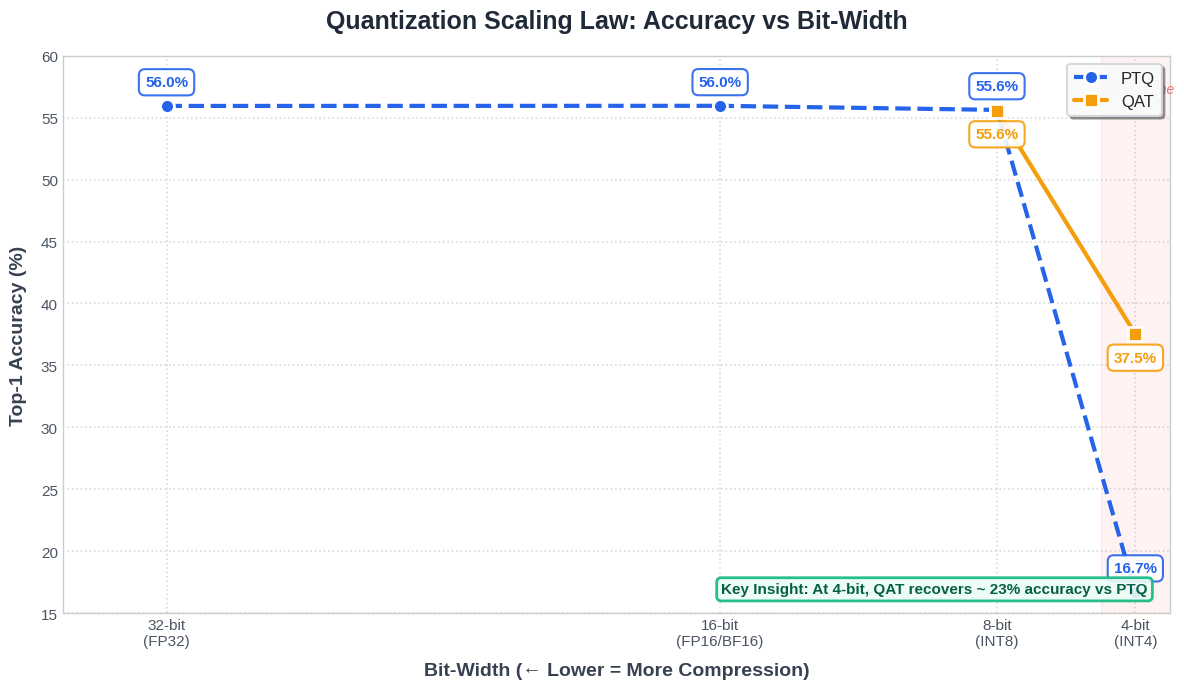


Plot saved as 'quantization_scaling_law.png'

Summary Statistics:
  • PTQ @ 4-bit: 16.7%
  • QAT @ 4-bit: 37.5%
  • Improvement: +20.8%


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- PTQ Results ----
results_data_ptq = [
    ['PTQ', 'fp32', 32, 55.95],
    ['PTQ', 'fp16', 16, 55.91],
    ['PTQ', 'bf16', 16, 56.01],
    ['PTQ', 'int8_symm', 8, 55.63],
    ['PTQ', 'int4_symm', 4, 14.70],
    ['PTQ', 'int4_asymm', 4, 18.69],
]
df_ptq = pd.DataFrame(results_data_ptq, columns=['Method', 'Precision', 'Bits', 'Accuracy'])

# ---- QAT Results ----
results_data_qat = [
    ['QAT', 'int8_symm', 8, 55.57],
    ['QAT', 'int4_symm', 4, 37.53],
]
df_qat = pd.DataFrame(results_data_qat, columns=['Method', 'Precision', 'Bits', 'Accuracy'])

# Aggregate data by bit-width (average if multiple entries)
df_ptq_agg = df_ptq.groupby('Bits')['Accuracy'].mean().reset_index()
df_qat_agg = df_qat.groupby('Bits')['Accuracy'].mean().reset_index()

# ---- Create Beautiful Plot ----
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors
ptq_color = '#2563eb'  # Blue
qat_color = '#f59e0b'  # Orange

# Sort by bits descending
df_ptq_agg = df_ptq_agg.sort_values('Bits', ascending=False)
df_qat_agg = df_qat_agg.sort_values('Bits', ascending=False)

# Plot PTQ (dashed line)
ax.plot(df_ptq_agg['Bits'], df_ptq_agg['Accuracy'], 
        marker='o', markersize=10, linewidth=3, color=ptq_color,
        linestyle='--', label='PTQ', 
        markeredgewidth=2, markeredgecolor='white', zorder=3)

# Plot QAT (solid line)
ax.plot(df_qat_agg['Bits'], df_qat_agg['Accuracy'], 
        marker='s', markersize=10, linewidth=3, color=qat_color,
        linestyle='-', label='QAT',
        markeredgewidth=2, markeredgecolor='white', zorder=3)

# Annotate PTQ points (ABOVE the line)
for _, row in df_ptq_agg.iterrows():
    ax.annotate(f"{row['Accuracy']:.1f}%", 
                xy=(row['Bits'], row['Accuracy']),
                xytext=(0, 12),  # Offset upward
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=ptq_color,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor=ptq_color, alpha=0.9, linewidth=1.5))

# Annotate QAT points (BELOW the line)
for _, row in df_qat_agg.iterrows():
    ax.annotate(f"{row['Accuracy']:.1f}%", 
                xy=(row['Bits'], row['Accuracy']),
                xytext=(0, -12),  # Offset downward
                textcoords='offset points',
                ha='center', va='top',
                fontsize=11, fontweight='bold', color=qat_color,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor=qat_color, alpha=0.9, linewidth=1.5))

# Titles & labels
ax.set_title('Quantization Scaling Law: Accuracy vs Bit-Width', 
             fontsize=18, weight='bold', pad=20, color='#1f2937')
ax.set_xlabel('Bit-Width (← Lower = More Compression)', 
              fontsize=14, labelpad=10, weight='semibold', color='#374151')
ax.set_ylabel('Top-1 Accuracy (%)', 
              fontsize=14, labelpad=10, weight='semibold', color='#374151')

# Axes settings
ax.set_xticks([32, 16, 8, 4])
ax.set_xticklabels(['32-bit\n(FP32)', '16-bit\n(FP16/BF16)', '8-bit\n(INT8)', '4-bit\n(INT4)'])
ax.invert_xaxis()
ax.set_xlim(35, 3)
ax.set_ylim(15, 60)
ax.tick_params(axis='both', labelsize=11, colors='#4b5563')

# Enhanced grid
ax.grid(True, linestyle=':', linewidth=1.2, alpha=0.4, color='#9ca3af')
ax.set_axisbelow(True)

# Legend with better styling
legend = ax.legend(loc='upper right', frameon=True, fontsize=12, 
                   shadow=True, fancybox=True, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#d1d5db')
legend.get_frame().set_linewidth(1.5)

# Add background shading for dramatic effect at 4-bit
ax.axvspan(3, 5, alpha=0.05, color='red', zorder=0)
ax.text(4, 57, 'Critical Zone', fontsize=10, ha='center', 
        style='italic', color='#dc2626', alpha=0.6)

# Add insight box
textstr = 'Key Insight: At 4-bit, QAT recovers ~ 23% accuracy vs PTQ'
props = dict(boxstyle='round', facecolor='#ecfdf5', edgecolor='#10b981', 
             alpha=0.9, linewidth=2)
ax.text(0.98, 0.03, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=props, weight='semibold', color='#065f46')

# Tight layout
plt.tight_layout()
plt.savefig('quantization_scaling_law.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\nPlot saved as 'quantization_scaling_law.png'")
print("\nSummary Statistics:")
print(f"  • PTQ @ 4-bit: {df_ptq_agg[df_ptq_agg['Bits']==4]['Accuracy'].values[0]:.1f}%")
print(f"  • QAT @ 4-bit: {df_qat_agg[df_qat_agg['Bits']==4]['Accuracy'].values[0]:.1f}%")
print(f"  • Improvement: +{df_qat_agg[df_qat_agg['Bits']==4]['Accuracy'].values[0] - df_ptq_agg[df_ptq_agg['Bits']==4]['Accuracy'].values[0]:.1f}%")

### Mixed Precisions

### Baselin (Uniform)

In [ ]:
print("\n--- Task 3: Mixed-Precision Quantization Analysis ---")

mixed_precision_results = []
dummy_input = torch.randn(1, 3, 32, 32, device=DEVICE)
model_to_quantize = deepcopy(vgg11_fp32)
low_bitwidth = 4

uniform_model = ptq_pipeline(model_to_quantize, calib_loader, DEVICE, bitwidth=low_bitwidth)
uniform_latency = measure_latency(uniform_model, DEVICE, dummy_input)
uniform_acc = evaluate(uniform_model, test_loader, DEVICE)    
uniform_size = get_model_size(uniform_model, bitwidth=low_bitwidth)                       
mixed_precision_results.append({
    'Config': f'Uniform INT{low_bitwidth}',
    'Accuracy': uniform_acc,
    'Size (MB)': uniform_size,
    'Latency (ms)': uniform_latency
})

print(f"Uniform INT{low_bitwidth} | "
      f"Accuracy: {uniform_acc:.2f}%, Size: {uniform_size:.2f} MB, "
      f"Latency: {uniform_latency:.3f} ms")

### Simple Mixed Precision

In [ ]:
# --- (ii) Simple Mixed-Precision (First and Last Layers in FP32) ---
print("\n--- Running Simple Mixed-Precision (First/Last Layer in FP32) ---")
model_simple_mixed = deepcopy(vgg11_fp32)
# For VGG-11: 'features.0' is the first conv, 'classifier.6' is the last linear layer
high_precision_layers = ['features.0', 'classifier.6']
simple_policy = {name: 32 if name in high_precision_layers else low_bitwidth for name, mod in model_simple_mixed.named_modules() if isinstance(mod, (nn.Conv2d, nn.Linear))}

model_simple_mixed = bnfold_vgg(model_simple_mixed, DEVICE)
observers = calibrate_model(model_simple_mixed, calib_loader, DEVICE, bitwidth=low_bitwidth)
model_simple_mixed = apply_mixed_precision_ptq(model_simple_mixed, observers, simple_policy, low_bitwidth=low_bitwidth)
model_simple_mixed = convert_to_mixed_precision_model(model_simple_mixed, simple_policy, low_bitwidth=low_bitwidth)

simple_mixed_acc = evaluate(model_simple_mixed, test_loader, DEVICE)
simple_mixed_size = get_model_size(model_simple_mixed, bitwidth=low_bitwidth) # Use get_model_size as it has FP32 parts
simple_mixed_latency = measure_latency(model_simple_mixed, DEVICE, dummy_input)
mixed_precision_results.append({'Config': 'Simple Mixed', 'Accuracy': simple_mixed_acc, 'Size (MB)': simple_mixed_size, 'Latency (ms)': simple_mixed_latency})
print(f"Simple Mixed | Accuracy: {simple_mixed_acc:.2f}%, Size: {simple_mixed_size:.2f} MB, Latency: {simple_mixed_latency:.3f} ms")

### Adaptive Mixed Precision

In [ ]:
# --- (iii) Adaptive Mixed-Precision (Variance-Based) ---
print("\n--- Running Adaptive Mixed-Precision (Variance-Based) ---")
model_adaptive_mixed = deepcopy(vgg11_fp32)

# <<< FIX: Fold the Batch Norm layers FIRST, before any analysis >>>
print("Folding Batch Normalization layers...")
model_adaptive_mixed = bnfold_vgg(model_adaptive_mixed, DEVICE)

# Now, perform all analysis on the SAME, consistent, folded model
manager = MixedPrecisionManager(model_adaptive_mixed, calib_loader)
print("Profiling the FOLDED model for activation variance...")
variances = manager.profile_activation_variance(device=DEVICE)

# Keep top 20% most sensitive layers in FP32
adaptive_policy = manager.get_quantization_policy(variances, sensitivity_percentile=0.5, high_precision_bits=32, low_precision_bits=low_bitwidth)

# Calibrate the FOLDED model
print("Calibrating the FOLDED model...")
observers = calibrate_model(model_adaptive_mixed, calib_loader, DEVICE, bitwidth=low_bitwidth)

# Apply quantization and convert
model_adaptive_mixed = apply_mixed_precision_ptq(model_adaptive_mixed, observers, adaptive_policy, low_bitwidth=low_bitwidth)
model_adaptive_mixed = convert_to_mixed_precision_model(model_adaptive_mixed, adaptive_policy, low_bitwidth=low_bitwidth)

adaptive_mixed_acc = evaluate(model_adaptive_mixed, test_loader, DEVICE)
adaptive_mixed_size = get_model_size(model_adaptive_mixed, bitwidth=low_bitwidth)
adaptive_mixed_latency = measure_latency(model_adaptive_mixed, DEVICE, dummy_input)
mixed_precision_results.append({'Config': 'Adaptive Mixed', 'Accuracy': adaptive_mixed_acc, 'Size (MB)': adaptive_mixed_size, 'Latency (ms)': adaptive_mixed_latency})
print(f"Adaptive Mixed | Accuracy: {adaptive_mixed_acc:.2f}%, Size: {adaptive_mixed_size:.2f} MB, Latency: {adaptive_mixed_latency:.3f} ms")

### Plotting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Data ---
data = [
    ['Uniform INT4', 14.32, 7.371],
    ['Simple Mixed', 30.20, 6.534],
    ['Adaptive Mixed', 38.80, 2.519],
]

df_plot = pd.DataFrame(data, columns=['Config', 'Accuracy', 'Latency'])

# --- Sort by Accuracy (descending for visualization) ---
df_plot = df_plot.sort_values('Accuracy', ascending=True)
configs = df_plot['Config'].tolist()
accuracies = df_plot['Accuracy'].values
latencies = df_plot['Latency'].values
y = np.arange(len(df_plot))

# --- Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = plt.get_cmap('Blues')(np.linspace(0.4, 0.9, len(df_plot)))
bars = ax.barh(y, accuracies, color=bar_colors, edgecolor='white', height=0.55, zorder=3)

# --- Annotate accuracy & latency ---
for bar, acc, lat in zip(bars, accuracies, latencies):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{acc:.2f}%  |  {lat:.3f} ms",
            va='center', fontsize=10, weight='semibold', color='#1f2937')

# --- Styling ---
ax.set_yticks(y)
ax.set_yticklabels(configs, fontsize=11, weight='semibold')
ax.set_xlabel('Top-1 Accuracy (%)', fontsize=12, labelpad=8, color='#374151')
ax.set_title('Mixed-Precision Quantization — Accuracy & Latency Comparison',
             fontsize=15, weight='bold', pad=12, color='#1f2937')

ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_xlim(0, max(accuracies) * 1.25)
ax.invert_yaxis()

# --- Insight box (optional) ---
best_cfg = df_plot.iloc[-1]
textstr = f"Best Config: {best_cfg['Config']} → {best_cfg['Accuracy']:.2f}% @ {best_cfg['Latency']:.3f} ms"
props = dict(boxstyle='round,pad=0.4', facecolor='#ecfdf5', edgecolor='#10b981', alpha=0.9, linewidth=2)
ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=props, color='#065f46', weight='semibold')

plt.tight_layout()
plt.savefig('mixed_precision_accuracy_latency.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- Report summary ---
print("\n--- Mixed Precision Quantization Summary ---")
for _, row in df_plot.iterrows():
    print(f"  • {row['Config']}: Accuracy = {row['Accuracy']:.2f}%, Latency = {row['Latency']:.3f} ms")

best = df_plot.iloc[-1]
print(f"\nBest Config: {best['Config']} ({best['Accuracy']:.2f}% @ {best['Latency']:.3f} ms)")


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Data ---
data = [
    ['Uniform INT4', 14.32, 61.63],
    ['Simple Mixed', 30.20, 63.01],
    ['Adaptive Mixed', 38.80, 412.90],
]
df = pd.DataFrame(data, columns=['Config', 'Accuracy', 'Size (MB)'])

# --- Baseline ---
baseline_size, baseline_acc = 492.81, 55.95

# --- Sort for line plotting (Pareto frontier style) ---
df = df.sort_values('Size (MB)')

# --- Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 5.5))

colors = ['#dc2626', '#2563eb', '#16a34a']
markers = ['o', 's', '^']

# Plot connecting line (Pareto-like)
ax.plot(df['Size (MB)'], df['Accuracy'], color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=1)

# Plot each configuration
for i, row in df.iterrows():
    ax.scatter(row['Size (MB)'], row['Accuracy'],
               s=220, color=colors[i], marker=markers[i], edgecolor='white', linewidth=1.5,
               label=row['Config'], zorder=3)
    ax.text(row['Size (MB)'] + 12, row['Accuracy'] + 0.4, 
            f"{row['Accuracy']:.1f}%", fontsize=10, weight='semibold', color=colors[i])

# --- FP32 Baseline ---
ax.axhline(y=baseline_acc, color='grey', linestyle=':', linewidth=1.3)
ax.scatter(baseline_size, baseline_acc, c='grey', marker='X', s=220, label='FP32 Baseline', zorder=3)
ax.text(baseline_size - 80, baseline_acc + 0.8, "FP32 (55.95%, 492.8 MB)",
        fontsize=10, color='gray', ha='right', style='italic')

# --- Annotations for trade-off insight ---
ax.annotate('Lower size →', xy=(80, 13), xytext=(180, 20),
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
            fontsize=9.5, color='black')

ax.annotate('→ Higher accuracy', xy=(380, 32), xytext=(440, 38),
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'),
            fontsize=9.5, color='black')

# --- Titles & Labels ---
ax.set_title('Mixed-Precision Quantization: Accuracy–Size Trade-off', fontsize=15, weight='bold', pad=12)
ax.set_xlabel('Model Size (MB)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)

# --- Limits & Grid ---
ax.set_xlim(0, 520)
ax.set_ylim(10, 60)
ax.grid(True, linestyle='--', alpha=0.5)

# --- Legend ---
ax.legend(title='Configurations', fontsize=10, loc='lower right', frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig('mixed_precision_tradeoff_curve.png', dpi=300, bbox_inches='tight')
plt.show()


### Visualizing Activation Outliers

In [ ]:
print("\n--- Task 4: Effect of Outliers on Quantization ---")

# --- Layers to Inspect ---
layers_to_inspect = [
    'features.0', 'features.3', 'features.8', 'features.13', 'features.20',
    'classifier.0', 'classifier.3', 'classifier.6'
]

visualizer = ActivationVisualizer(vgg11_fp32, layers_to_inspect)
print(f"Capturing activations for layers: {layers_to_inspect}")
visualizer.capture_activations(calib_loader, DEVICE)
visualizer.plot_histograms()
visualizer.remove_hooks()


### Clipped Quantization

In [ ]:
from copy import deepcopy

print("\n=== Comparing Standard vs. Clipped PTQ ===")

comparison_results = []

for bitwidth in [4, 8]:
    print(f"\n--- {bitwidth}-bit Quantization ---")

    # --- Standard PTQ ---
    print(f"Running Standard PTQ ({bitwidth}-bit)...")
    model_std = ptq_pipeline(deepcopy(vgg11_fp32), calib_loader, DEVICE, bitwidth=bitwidth)
    acc_std = evaluate(model_std, test_loader, DEVICE)
    print(f"Standard PTQ ({bitwidth}-bit) Accuracy: {acc_std:.2f}%")

    # --- Clipped PTQ ---
    print(f"Running Clipped PTQ ({bitwidth}-bit, 99.9th percentile)...")
    model_clip = ptq_pipeline_clipped(deepcopy(vgg11_fp32), calib_loader, DEVICE, bitwidth=bitwidth, percentile=99.9)
    acc_clip = evaluate(model_clip, test_loader, DEVICE)
    print(f"Clipped PTQ ({bitwidth}-bit) Accuracy: {acc_clip:.2f}%")

    # --- Record Results ---
    comparison_results.append({
        "Precision": f"INT{bitwidth}",
        "Standard Accuracy": acc_std,
        "Clipped Accuracy": acc_clip,
        "Diff": acc_clip - acc_std
    })

# --- Convert to DataFrame for Easy Viewing ---
df_comparison = pd.DataFrame(comparison_results)
print("\n=== PTQ Comparison Results ===")
print(df_comparison.to_string(index=False))

# --- Beautiful Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_comparison))
width = 0.35

bars1 = ax.bar(x - width/2, df_comparison["Standard Accuracy"], width, label='Standard PTQ', alpha=0.8)
bars2 = ax.bar(x + width/2, df_comparison["Clipped Accuracy"], width, label='Clipped PTQ (99.9%)', alpha=0.8)

# Annotate values on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.2, f"{height:.2f}", ha='center', va='bottom', fontsize=10)

ax.set_title("Standard vs. Clipped PTQ Accuracy", fontsize=15, weight='bold')
ax.set_ylabel("Top-1 Accuracy (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_comparison["Precision"], fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
layers_to_inspect = [
    'features.0', 'features.3', 'features.8', 'features.13', 'features.20',
    'classifier.0', 'classifier.3', 'classifier.6'
]
clip_visualizer = ClippedActivationVisualizer(vgg11_fp32, layers_to_inspect)
print("\n--- Visualizing the Effect of Clipping on Activation Distributions ---")
clip_visualizer.capture_activations(calib_loader, DEVICE)
clip_visualizer.plot_clipped_distributions(percentile=99.9)
clip_visualizer.remove_hooks()
print("\nPlot saved as 'clipped_distributions_visualization.png'")